Aquí tienes el script en Python para implementar la **Recomendación 1 (Análisis de Componentes Principales - PCA)** aplicada de manera rigurosa al bloque de variables meteorológicas exógenas y sus rezagos.

# Características del Script:

1. **Conservación de la Inercia**: Separa la variable objetivo (`casos_dengue`) y sus propios rezagos para **no** aplicarles PCA, tal como dicta la recomendación teórica.
2. **Escalamiento Previo Estricto**: Aplica `StandardScaler` únicamente a las variables meteorológicas antes de computar PCA (paso obligatorio dado que las variables tienen diferentes unidades como °C, mm de lluvia, etc.).
3. **Criterio de Varianza Explicada**: El algoritmo calcula automáticamente cuántos componentes se necesitan para retener el **85% de la varianza climática total**, reduciendo drásticamente las dimensiones sin perder información valiosa.
4. **Exportación Consistente**: Guarda el nuevo dataset procesado en formato Excel en la ruta solicitada.



[INFO] Leyendo dataset de alta dimensionalidad desde:
C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\5_recomendacion_estadistica_1\2_datos\1_raw\2_meteo_epi_rezagos_meteo_epi.xlsx
--> Columnas de la inercia del dengue detectadas (No sufren PCA): 13
--> Columnas meteorológicas totales detectadas (Sufren PCA): 143

[INFO] Escalando variables meteorológicas (Media=0, Varianza=1)...
[INFO] Ajustando Análisis de Componentes Principales (PCA)...
--> Para explicar el 85% de la varianza climática se requieren: 26 componentes principales.

[INFO] Dataset original reducido exitosamente.
--> Dimensiones originales: (249, 159)
--> Dimensiones del nuevo dataset reducido: (249, 42)
[INFO] Guardando archivo Excel procesado en:
C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\5_recomendacion_estadistica_1\2_datos\2_procesados\dataset_reducido_pca.xlsx
[ÉXITO] Proceso de reducción dimensional finalizado correctamente.
[IN

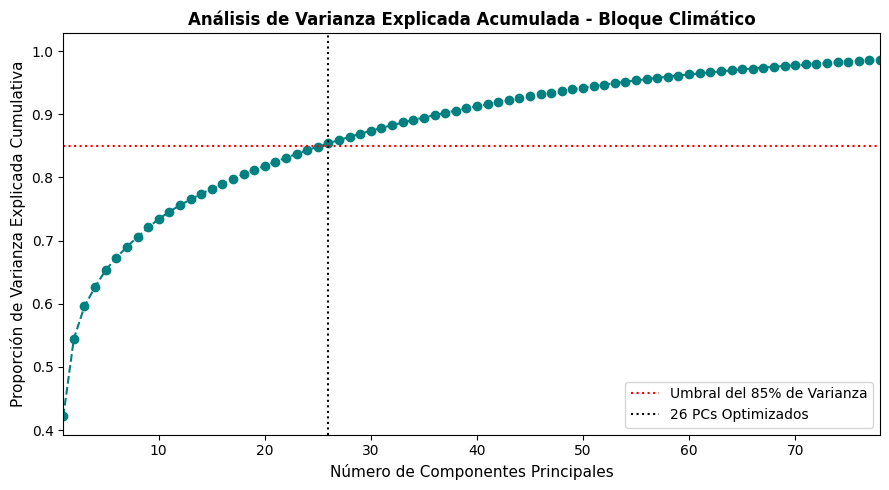

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =============================================================================
# PASO 1: CONFIGURACIÓN DE RUTAS Y CARGA DE DATOS
# =============================================================================
ruta_lectura = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\5_recomendacion_estadistica_1\2_datos\1_raw\2_meteo_epi_rezagos_meteo_epi.xlsx"
directorio_guardado = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\5_recomendacion_estadistica_1\2_datos\2_procesados"

os.makedirs(directorio_guardado, exist_ok=True)
ruta_guardado = os.path.join(directorio_guardado, "dataset_reducido_pca.xlsx")

print(f"[INFO] Leyendo dataset de alta dimensionalidad desde:\n{ruta_lectura}")
df = pd.read_excel(ruta_lectura)

# Guardar columnas de control temporal que no entran al PCA ni son regresores directos
columnas_control = [col for col in ['fecha', 'año', 'semana_epi'] if col in df.columns]
df_control = df[columnas_control].copy()

# =============================================================================
# PASO 2: SEPARACIÓN DE BLOQUES (INERCIA DEL DENGUE VS METEOROLOGÍA)
# =============================================================================
# Identificar la variable objetivo y todos sus rezagos directos (Inercia sagrada)
columnas_dengue = [col for col in df.columns if 'casos_dengue' in col]

# El resto de columnas no temporales ni de dengue corresponden al bloque meteorológico exógeno
columnas_excluir = columnas_control + columnas_dengue + ['casos_ln']
columnas_meteorologicas = [col for col in df.columns if col not in columnas_excluir]

print(f"--> Columnas de la inercia del dengue detectadas (No sufren PCA): {len(columnas_dengue)}")
print(f"--> Columnas meteorológicas totales detectadas (Sufren PCA): {len(columnas_meteorologicas)}")

# Extraer matrices individuales
X_meteo = df[columnas_meteorologicas].copy()
df_dengue_bloque = df[columnas_dengue].copy()

# Limpieza preventiva por si existen filas con nulos debido a rezagos previos
indices_validos = X_meteo.dropna().index
X_meteo = X_meteo.loc[indices_validos]
df_dengue_bloque = df_dengue_bloque.loc[indices_validos]
df_control = df_control.loc[indices_validos]

# =============================================================================
# PASO 3: ESCALAMIENTO Y AJUSTE DE PCA SOBRE EL BLOQUE CLIMÁTICO
# =============================================================================
print("\n[INFO] Escalando variables meteorológicas (Media=0, Varianza=1)...")
scaler = StandardScaler()
X_meteo_scaled = scaler.fit_transform(X_meteo)

print("[INFO] Ajustando Análisis de Componentes Principales (PCA)...")
# Inicializamos PCA sin límite para evaluar la curva de varianza explicada acumulada
pca_completo = PCA()
pca_completo.fit(X_meteo_scaled)

# Encontrar el número de componentes necesarios para explicar el 85% de la varianza
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)
n_componentes_opt = np.argmax(varianza_acumulada >= 0.85) + 1

print(f"--> Para explicar el 85% de la varianza climática se requieren: {n_componentes_opt} componentes principales.")

# Aplicar el PCA definitivo con el número óptimo de componentes
pca_definitivo = PCA(n_components=n_componentes_opt)
componentes_principales = pca_definitivo.fit_transform(X_meteo_scaled)

# Crear un DataFrame con las nuevas variables sintéticas (Componentes)
nombres_componentes = [f"PC_clima_{i+1}" for i in range(n_componentes_opt)]
df_pca = pd.DataFrame(componentes_principales, columns=nombres_componentes, index=indices_validos)

# =============================================================================
# PASO 4: CONSOLIDACIÓN DEL DATASET REDUCIDO Y EXPORTACIÓN
# =============================================================================
# Concatenar horizontalmente: Control Temporal + Inercia Dengue + Componentes Climáticos
df_final_reducido = pd.concat([df_control, df_dengue_bloque, df_pca], axis=1)

print(f"\n[INFO] Dataset original reducido exitosamente.")
print(f"--> Dimensiones originales: {df.shape}")
print(f"--> Dimensiones del nuevo dataset reducido: {df_final_reducido.shape}")

print(f"[INFO] Guardando archivo Excel procesado en:\n{ruta_guardado}")
df_final_reducido.to_excel(ruta_guardado, index=False)
print("[ÉXITO] Proceso de reducción dimensional finalizado correctamente.")

# =============================================================================
# PASO 5: GRÁFICO INFORMATIVO DE VARIANZA EXPLICADA (OPCIONAL)
# =============================================================================
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='teal')
plt.axhline(y=0.85, color='r', linestyle=':', label='Umbral del 85% de Varianza')
plt.axvline(x=n_componentes_opt, color='black', linestyle=':', label=f'{n_componentes_opt} PCs Optimizados')
plt.title('Análisis de Varianza Explicada Acumulada - Bloque Climático', fontsize=12, fontweight='bold')
plt.xlabel('Número de Componentes Principales', fontsize=11)
plt.ylabel('Proporción de Varianza Explicada Cumulativa', fontsize=11)
plt.xlim(1, min(len(varianza_acumulada), n_componentes_opt * 3)) # Acotar el eje X para legibilidad
plt.legend(loc='lower right')
plt.tight_layout()

ruta_grafico = os.path.join(directorio_guardado, "varianza_explicada_pca.png")
plt.savefig(ruta_grafico, dpi=300)
print(f"[INFO] Gráfico de codo de varianza guardado en:\n{ruta_grafico}")
plt.show()



# Implementación del dataset anterior al algoritmo arimax

Para adaptar y corregir el pipeline multi-criterio de modo que funcione a la perfección con tu nuevo dataset reducido por PCA, debemos tener en cuenta una regla fundamental de los modelos lineales como ARIMAX: **la escala**.

Los componentes principales generados por el PCA (`PC_clima_1`, `PC_clima_2`, etc.) ya se encuentran en una escala homogénea estandarizada debido al `StandardScaler` que aplicaste antes de transformarlos. Por lo tanto, en este nuevo script:

1. **No volvemos a aplicar `StandardScaler` a los componentes climáticos**, ya que alteraríamos las varianzas relativas que el PCA se esforzó en calcular.
2. **Sí escalamos de forma independiente los rezagos de `casos_dengue**` (`casos_dengue_lag_1`, etc.), puesto que estos todavía se encuentran en su escala original de conteo (unidades enteras de personas).

Aquí tienes el script completamente corregido y optimizado para procesar el dataset reducido:



In [4]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN
# =============================================================================
import os
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DEL DATASET REDUCIDO POR PCA
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\5_recomendacion_estadistica_1\2_datos\2_procesados\dataset_reducido_pca.xlsx"
dir_resultados = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\5_recomendacion_estadistica_1\3_resultados"

os.makedirs(dir_resultados, exist_ok=True)

print(f"[INFO] Cargando dataset reducido por PCA desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos)

# Forzar formato de fecha e indexación temporal semanal
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
df.set_index('fecha', inplace=True)
df = df.asfreq('W')
df = df.ffill().bfill()

# Identificar dinámicamente el rango de años del dataset para títulos y nombres de archivos
anio_min = df.index.year.min()
anio_max = df.index.year.max()
periodo_str = f"{anio_min}-{anio_max}"
print(f"[INFO] Periodo temporal detectado en los datos: {periodo_str}")

# =============================================================================
# PASO 3: AISLAMIENTO DE VARIABLES (INERCIA VS EXÓGENAS PCA)
# =============================================================================
y = df['casos_dengue']

# Las columnas exógenas ahora son los rezagos del dengue y los Componentes Principales climáticos (PC_clima_X)
columnas_exclusoras = ['casos_dengue', 'año', 'semana_epi', 'casos_ln']
columnas_exogenas = [col for col in df.columns if col not in columnas_exclusoras]
X_features = df[columnas_exogenas]

print(f"[INFO] Variables exógenas a utilizar (PCA + Rezagos Dengue): {columnas_exogenas}")

# =============================================================================
# PASO 4: REJILLA DE PARTICIONES Y EVALUACIÓN DE LOS CUATRO CRITERIOS (AICc, BIC, AIC, HQIC)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Los 4 criterios estadísticos soportados por pmdarima para ARIMAX
criterios = ['aicc', 'bic', 'aic', 'hqic']
resultados_globales = []

for criterio in criterios:
    print("\n" + "#"*85)
    print(f" INICIANDO OPTIMIZACIÓN BAJO EL CRITERIO ESTADÍSTICO: {criterio.upper()}")
    print("#"*85)
    
    # Inicialización del lienzo gráfico (3 particiones x 2 columnas [Train / Test])
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
    
    for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
        print(f"\n[Procesando Partición {nombre_split} - Criterio {criterio.upper()}]")
        
        # 1. División temporal estricta
        tamanio_train = int(len(df) * tasa_train)
        y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
        X_train, X_test = X_features.iloc[:tamanio_train], X_features.iloc[tamanio_train:]
        
        y_train.index.freq = 'W'
        y_test.index.freq = 'W'
        X_train.index.freq = 'W'
        X_test.index.freq = 'W'
        
        # 2. Escalamiento estándar de la matriz exógena (Sigue siendo buena práctica con PCs)
        preprocessor = ColumnTransformer(
            transformers=[('num', StandardScaler(), columnas_exogenas)],
            remainder='drop'
        )
        X_train_scaled = pd.DataFrame(preprocessor.fit_transform(X_train), index=X_train.index, columns=columnas_exogenas)
        X_test_scaled = pd.DataFrame(preprocessor.transform(X_test), index=X_test.index, columns=columnas_exogenas)
        X_train_scaled.index.freq = 'W'
        X_test_scaled.index.freq = 'W'
        
        # 3. Identificación del orden óptimo mediante auto_arima usando el criterio del bucle
        modelo_auto = pm.auto_arima(
            y_train,
            X=X_train_scaled,                
            start_p=1, max_p=3,       
            start_q=1, max_q=3,       
            d=1,                      
            seasonal=False,           
            stationary=False,
            information_criterion=criterio, 
            error_action='ignore',   
            suppress_warnings=True,  
            stepwise=True             
        )
        
        p, d_ord, q = modelo_auto.order
        orden_ordinario_opt = (p, d_ord, q)
        
        # 4. Ajuste final del modelo ARIMAX por Máxima Verosimilitud
        modelo_final = SARIMAX(
            y_train,
            exog=X_train_scaled,
            order=orden_ordinario_opt,
            seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(method='lbfgs', maxiter=50, disp=False)
        
        # Extraer dinámicamente el valor del indicador evaluado actual
        if criterio == 'aicc': valor_metric_criterio = modelo_final.aicc
        elif criterio == 'bic': valor_metric_criterio = modelo_final.bic
        elif criterio == 'aic': valor_metric_criterio = modelo_final.aic
        else: valor_metric_criterio = modelo_final.hqic # hqic
        
        # 5. Generación de predicciones
        y_train_pred = modelo_final.predict(start=y_train.index[0], end=y_train.index[-1], exog=X_train_scaled)
        y_train_pred.iloc[:(d_ord + 1)] = np.nan  
        
        y_test_pred = modelo_final.predict(start=y_test.index[0], end=y_test.index[-1], exog=X_test_scaled)
        y_test_pred = pd.Series(y_test_pred, index=y_test.index)
        
        # 6. Alineación y cálculo del error (MAE)
        y_train_limpio = y_train.dropna()
        y_train_pred_limpio = y_train_pred.dropna()
        
        y_train_alined, y_train_pred_alined = y_train_limpio.align(y_train_pred_limpio, join='inner')
        y_test_alined, y_test_pred_alined = y_test.dropna().align(y_test_pred.dropna(), join='inner')
        
        mae_train = mean_absolute_error(y_train_alined, y_train_pred_alined)
        mae_test = mean_absolute_error(y_test_alined, y_test_pred_alined)
        
        # Guardar resultados consolidados
        resultados_globales.append({
            "Criterio": criterio.upper(),
            "Partición": nombre_split,
            "Orden óptimo": f"({p},{d_ord},{q})",
            "Valor Criterio": valor_metric_criterio,
            "MAE Train": mae_train,
            "MAE Test": mae_test
        })
        
        # =========================================================================
        # PASO 5: MAQUETACIÓN GRÁFICA DE RESULTADOS
        # =========================================================================
        ax_train = axes[idx, 0]
        ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
        ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho', color='#ff7f0e', linestyle='--')
        ax_train.set_title(f"Ajuste Train ({nombre_split}) - Orden: {orden_ordinario_opt} (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
        ax_train.set_ylabel('casos_dengue', fontsize=10)
        ax_train.legend(loc='upper left', fontsize=9)
        
        ax_test = axes[idx, 1]
        ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
        ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico', color='#d62728', linestyle='--')
        ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
        ax_test.legend(loc='upper left', fontsize=9)

    # Inclusión del rango de años dinámico en la parte superior de cada lienzo explicativo
    plt.suptitle(f'Pipeline ARIMAX - Evaluación usando Criterio: {criterio.upper()}\nDataset Reducido PCA | Periodo Evaluado: {periodo_str}', 
                 fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    # Inclusión del rango de años dinámico en el nombre del archivo .png de salida
    ruta_grafico_criterio = os.path.join(dir_resultados, f"reporte_arimax_criterio_{criterio}_{periodo_str}.png")
    plt.savefig(ruta_grafico_criterio, dpi=300, bbox_inches='tight')
    print(f"[INFO] Gráfico para el criterio {criterio.upper()} guardado con éxito.")
    plt.close() # Cerrar ventana para liberar memoria en ciclos largos

# =============================================================================
# PASO 6: CONSOLIDACIÓN TABULAR Y EXPORTACIÓN EXCEL
# =============================================================================
df_reporte_base = pd.DataFrame(resultados_globales)

lista_con_promedios = []
for crit, sub_df in df_reporte_base.groupby("Criterio"):
    lista_con_promedios.append(sub_df) # Filas de las particiones
    
    # Calcular fila del promedio por criterio
    fila_promedio = pd.DataFrame([{
        "Criterio": crit,
        "Partición": "PROMEDIO",
        "Orden óptimo": "-",
        "Valor Criterio": sub_df["Valor Criterio"].mean(),
        "MAE Train": sub_df["MAE Train"].mean(),
        "MAE Test": sub_df["MAE Test"].mean()
    }])
    lista_con_promedios.append(fila_promedio)

df_reporte_completo = pd.concat(lista_con_promedios, ignore_index=True)

# Imprimir reporte limpio en consola
print("\n" + "="*95)
print(f"   REPORTE CIENTÍFICO INTEGRAL COMPARATIVO: CUATRO CRITERIOS ARIMAX ({periodo_str})   ")
print("="*95)
print(df_reporte_completo.to_string(index=False, formatters={
    "Valor Criterio": "{:.4f}".format,
    "MAE Train": "{:.4f}".format,
    "MAE Test": "{:.4f}".format
}))
print("="*95)

# Inclusión del rango de años dinámico en el nombre del reporte Excel final
ruta_excel = os.path.join(dir_resultados, f"comparativa_cuatro_criterios_arimax_{periodo_str}.xlsx")
df_reporte_completo.to_excel(ruta_excel, index=False)
print(f"\n[ÉXITO] Base de datos de rendimientos consolidada y guardada en:\n{ruta_excel}")

[INFO] Cargando dataset reducido por PCA desde:
C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\5_recomendacion_estadistica_1\2_datos\2_procesados\dataset_reducido_pca.xlsx
[INFO] Periodo temporal detectado en los datos: 2021-2025
[INFO] Variables exógenas a utilizar (PCA + Rezagos Dengue): ['casos_dengue_lag_1', 'casos_dengue_lag_2', 'casos_dengue_lag_3', 'casos_dengue_lag_4', 'casos_dengue_lag_5', 'casos_dengue_lag_6', 'casos_dengue_lag_7', 'casos_dengue_lag_8', 'casos_dengue_lag_9', 'casos_dengue_lag_10', 'casos_dengue_lag_11', 'casos_dengue_lag_12', 'PC_clima_1', 'PC_clima_2', 'PC_clima_3', 'PC_clima_4', 'PC_clima_5', 'PC_clima_6', 'PC_clima_7', 'PC_clima_8', 'PC_clima_9', 'PC_clima_10', 'PC_clima_11', 'PC_clima_12', 'PC_clima_13', 'PC_clima_14', 'PC_clima_15', 'PC_clima_16', 'PC_clima_17', 'PC_clima_18', 'PC_clima_19', 'PC_clima_20', 'PC_clima_21', 'PC_clima_22', 'PC_clima_23', 'PC_clima_24', 'PC_clima_25', 'PC_clima_26']

#################

c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



[Procesando Partición 96-4 - Criterio AICC]


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



[Procesando Partición 97-3 - Criterio AICC]


...


[Procesando Partición 96-4 - Criterio HQIC]


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



[Procesando Partición 97-3 - Criterio HQIC]


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[INFO] Gráfico para el criterio HQIC guardado con éxito.

   REPORTE CIENTÍFICO INTEGRAL COMPARATIVO: CUATRO CRITERIOS ARIMAX (2021-2025)   
Criterio Partición Orden óptimo Valor Criterio MAE Train MAE Test
     AIC      95-5      (0,1,1)      1678.9895    5.4030  18.4615
     AIC      96-4      (0,1,1)      1703.2145    5.4407   9.1176
     AIC      97-3      (0,1,1)      1715.8501    5.4211  11.7701
     AIC  PROMEDIO            -      1699.3514    5.4216  13.1164
    AICC      95-5      (0,1,1)      1696.0728    5.4030  18.4615
    AICC      96-4      (0,1,1)      1720.0351    5.4407   9.1176
    AICC      97-3      (0,1,1)      1732.4999    5.4211  11.7701
    AICC  PROMEDIO            -      1716.2026    5.4216  13.1164
     BIC      95-5      (0,1,0)      1824.7086    5.3896  33.0362
     BIC      96-4      (0,1,0)      1849.3632    5.4125  14.7734
     BIC      97-3      (0,1,0)      1863.2477    5.4217  21.3544
     BIC  PROMEDIO            -      1845.7732    5.4079  23.0547
 